In [ ]:
import pandas as pd

df = pd.read_csv('long_method.csv', sep=';')
df.head()

,file,project,version,loc,lloc,sloc,comments,multi,blank,cyclo,...,V,D,E,T,B,cbo,lcom,DIT,rfc,LongMethod
0,django/apps/config.py,django-5.2,5.2,274.0,128.0,163.0,55.0,19.0,35.0,60.0,...,736.589,5.414,3987.94,221.552,0.24553,22.0,5.0,0.0,22.0,0
1,django/apps/registry.py,django-5.2,5.2,437.0,203.0,209.0,56.0,88.0,79.0,76.0,...,706.016,6.844,4.831.796,268.433,0.235339,35.0,1.0,0.0,54.0,0
2,django/apps/__init__.py,django-5.2,5.2,4.0,3.0,3.0,0.0,0.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,django/conf/global_settings.py,django-5.2,5.2,669.0,150.0,297.0,278.0,4.0,116.0,1.0,...,128.927,0.786,101.3,5.628,0.042976,0.0,0.0,0.0,0.0,0
4,django/conf/__init__.py,django-5.2,5.2,272.0,147.0,167.0,16.0,38.0,47.0,68.0,...,680.881,5.635,3.836.709,213.15,0.22696,44.0,3.0,1.0,22.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14383 entries, 0 to 14382
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   file        14383 non-null  object 
 1   project     14383 non-null  object 
 2   version     14383 non-null  object 
 3   loc         14383 non-null  float64
 4   lloc        14383 non-null  float64
 5   sloc        14383 non-null  float64
 6   comments    14383 non-null  float64
 7   multi       14383 non-null  float64
 8   blank       14383 non-null  float64
 9   cyclo       14383 non-null  float64
 10  wmc         14383 non-null  float64
 11  η1          14383 non-null  float64
 12  η2          14383 non-null  float64
 13  N1          14383 non-null  float64
 14  N2          14383 non-null  float64
 15  η           14383 non-null  float64
 16  N           14383 non-null  float64
 17  N_hat       14383 non-null  object 
 18  V           14383 non-null  object 
 19  D           14383 non-nul

In [ ]:
df['LongMethod'].unique()

array([0, 1])

In [ ]:
df.isnull().sum()

,0
file,0
project,0
version,0
loc,0
lloc,0
sloc,0
comments,0
multi,0
blank,0
cyclo,0


In [ ]:
print("Jumlah file:", df.shape[0])

Jumlah file: 14383


In [ ]:
len(df)

14383

In [ ]:
df['project'] = df['project'].str.replace(r'-.*$', '', regex=True)

In [ ]:
df.head()

,file,project,version,loc,lloc,sloc,comments,multi,blank,cyclo,...,V,D,E,T,B,cbo,lcom,DIT,rfc,LongMethod
0,django/apps/config.py,django,5.2,274.0,128.0,163.0,55.0,19.0,35.0,60.0,...,736.589,5.414,3987.94,221.552,0.24553,22.0,5.0,0.0,22.0,0
1,django/apps/registry.py,django,5.2,437.0,203.0,209.0,56.0,88.0,79.0,76.0,...,706.016,6.844,4.831.796,268.433,0.235339,35.0,1.0,0.0,54.0,0
2,django/apps/__init__.py,django,5.2,4.0,3.0,3.0,0.0,0.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,django/conf/global_settings.py,django,5.2,669.0,150.0,297.0,278.0,4.0,116.0,1.0,...,128.927,0.786,101.3,5.628,0.042976,0.0,0.0,0.0,0.0,0
4,django/conf/__init__.py,django,5.2,272.0,147.0,167.0,16.0,38.0,47.0,68.0,...,680.881,5.635,3.836.709,213.15,0.22696,44.0,3.0,1.0,22.0,0


In [ ]:
df['project'].unique()

array(['django', 'matplotlib', 'numpy', 'scipy'], dtype=object)

# **SPLIT DATA**

In [ ]:
from sklearn.model_selection import train_test_split

# Simpan metadata
meta = df[["file", "version", "project"]]

# Pisahkan fitur dan label
X = df.drop(columns=["file", "version", "project", "LongMethod"])
y = df["LongMethod"]

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, meta, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

forbidden = ["loc", "cyclo"]
X_train = X_train.drop(columns=forbidden)
X_test  = X_test.drop(columns=forbidden)

print("Fitur final:", X_train.columns.tolist())

Fitur final: ['lloc', 'sloc', 'comments', 'multi', 'blank', 'wmc', 'η1', 'η2', 'N1', 'N2', 'η', 'N', 'N_hat', 'V', 'D', 'E', 'T', 'B', 'cbo', 'lcom', 'DIT', 'rfc']


# **FEATURE SCALING**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class ModifiedZScoreScaler(BaseEstimator, TransformerMixin):
    """
    Modified Z-score scaling (median & MAD).
    Cocok untuk data skewed / outlier-heavy.
    """
    def fit(self, X, y=None):
        self.medians_ = X.median()
        self.mads_ = (np.abs(X - self.medians_)).median()
        self.mads_ = self.mads_.replace(0, 1e-9)
        return self

    def transform(self, X):
        return 0.6745 * (X - self.medians_) / self.mads_

In [ ]:
# Sebelum scaling
print("\n=== Sebelum Scaling ===")
print(X_train.head())

problematic_numeric_cols = ['N_hat', 'V', 'E', 'T', 'B']
for col in problematic_numeric_cols:
    # Check if the column exists in X_train and is of object type
    if col in X_train.columns and X_train[col].dtype == 'object':
        # Replace '.' thousand separator with '' and convert to float
        X_train[col] = X_train[col].str.replace('.', '', regex=False).astype(float)

# Scaling
scaler = ModifiedZScoreScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Setelah scaling
print("\n=== Setelah Scaling ===")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())


=== Sebelum Scaling ===
       lloc   sloc  comments  multi  blank    wmc    η1     η2     N1     N2  \
3350    3.0   12.0       4.0    0.0    4.0    0.0   0.0    0.0    0.0    0.0   
9059  411.0  436.0      76.0  179.0  106.0  110.0  16.0  170.0  101.0  188.0   
6627    9.0    8.0       0.0    3.0    1.0    0.0   0.0    0.0    0.0    0.0   
4561    0.0    0.0       0.0    0.0    0.0    0.0   0.0    0.0    0.0    0.0   
1699   52.0   47.0      11.0   27.0   26.0   10.0   2.0   10.0    7.0   11.0   

      ...      N_hat          V      D           E          T         B  cbo  \
3350  ...        0.0        0.0  0.000         0.0        0.0       0.0  0.0   
9059  ...  1.323.596  2.178.817  8.847  19.276.121  1.070.896  0.726272  0.0   
6627  ...        0.0        0.0  0.000         0.0        0.0       0.0  0.0   
4561  ...        0.0        0.0  0.000         0.0        0.0       0.0  0.0   
1699  ...     35.219     64.529  1.100      70.982      3.943   0.02151  8.0   

     lcom  DI

# **FEATURE SELECTION**

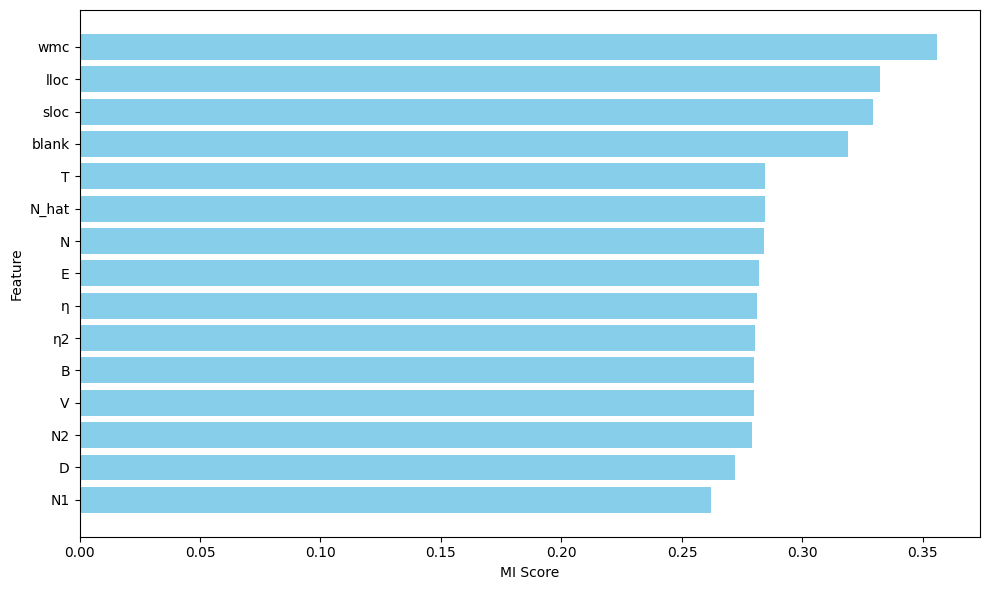

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import numpy as np

def select_topk_features_MI(X, y, k):
    """
    Feature selection menggunakan Mutual Information.
    Mengambil k fitur teratas berdasarkan skor MI.
    """
    scores = mutual_info_classif(X, y, random_state=42)
    mi_series = pd.Series(scores, index=X.columns)
    selected = mi_series.nlargest(k).index.tolist()
    return selected, scores

# top-k MI
selected_features, scores = select_topk_features_MI(X_train, y_train, k=15)

# Buat dataframe untuk plotting
mi_df = pd.DataFrame({
    "feature": X_train.columns,
    "mi_score": scores
}).sort_values("mi_score", ascending=True)

# Ambil data fitur yang terpilih
mi_selected_df = mi_df[mi_df["feature"].isin(selected_features)]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(mi_selected_df["feature"], mi_selected_df["mi_score"], color='skyblue')
# plt.title("Top-15 Features Based on Mutual Information")
plt.xlabel("MI Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# **MODELING**

# **RANDOM FOREST**

In [ ]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix
import numpy as np

n_estimators_list = [100, 200, 300]

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
# Untuk menyimpan hasil akhir per n_estimators
mean_acc_results = []
mean_mcc_results = []

for n in n_estimators_list:

    print("\n\n======================")
    print(f"   n_estimators = {n}")
    print("======================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []
    fold_counter = 1

    # === CV berjalan untuk setiap n_estimators ===
    for train_idx, test_idx in rskf.split(X_train, y_train):

        # === Ambil fold ===
        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        # === Feature Selection ===
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # === Scaling ===
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # === Model ===
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=7,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )

        # === Timing Training ===
        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        # === Timing Predict ===
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        # === Evaluasi ===
        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediksi Time:  {pred_time:.5f} sec")
        fold_counter += 1

    # === Hasil per konfigurasi n_estimators ===
    mean_acc_results.append(np.mean(acc_all))
    mean_mcc_results.append(np.mean(mcc_all))
    mean_train = np.mean(train_time_all)
    mean_pred = np.mean(predict_time_all)

    print("\n>>> RESULT for n_estimators =", n)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {mean_train:.5f} sec")
    print(f"Mean Predict Time:  {mean_pred:.5f} sec")



   n_estimators = 100

===== Fold 1 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'η', 'N2', 'η2', 'T', 'V', 'N_hat', 'E', 'B', 'N1', 'D']
Accuracy: 0.99218
MCC: 0.97104
Training Time:  0.87329 sec
Prediksi Time:  0.03588 sec

===== Fold 2 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η2', 'N_hat', 'N', 'η', 'T', 'E', 'N2', 'V', 'B', 'N1', 'D']
Accuracy: 0.98827
MCC: 0.95824
Training Time:  0.81885 sec
Prediksi Time:  0.03486 sec

===== Fold 3 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'N2', 'η', 'E', 'T', 'η2', 'N_hat', 'B', 'V', 'D', 'N1']
Accuracy: 0.99305
MCC: 0.97443
Training Time:  0.85102 sec
Prediksi Time:  0.03509 sec

===== Fold 4 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η2', 'η', 'N', 'N_hat', 'N2', 'T', 'E', 'V', 'B', 'N1', 'D']
Accuracy: 0.98957
MCC: 0.96201
Training Time:  1.47020 sec
Prediksi Time:  0.03569 sec

===== Fold 5 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η', 'η2', 'N', 'N_hat', 

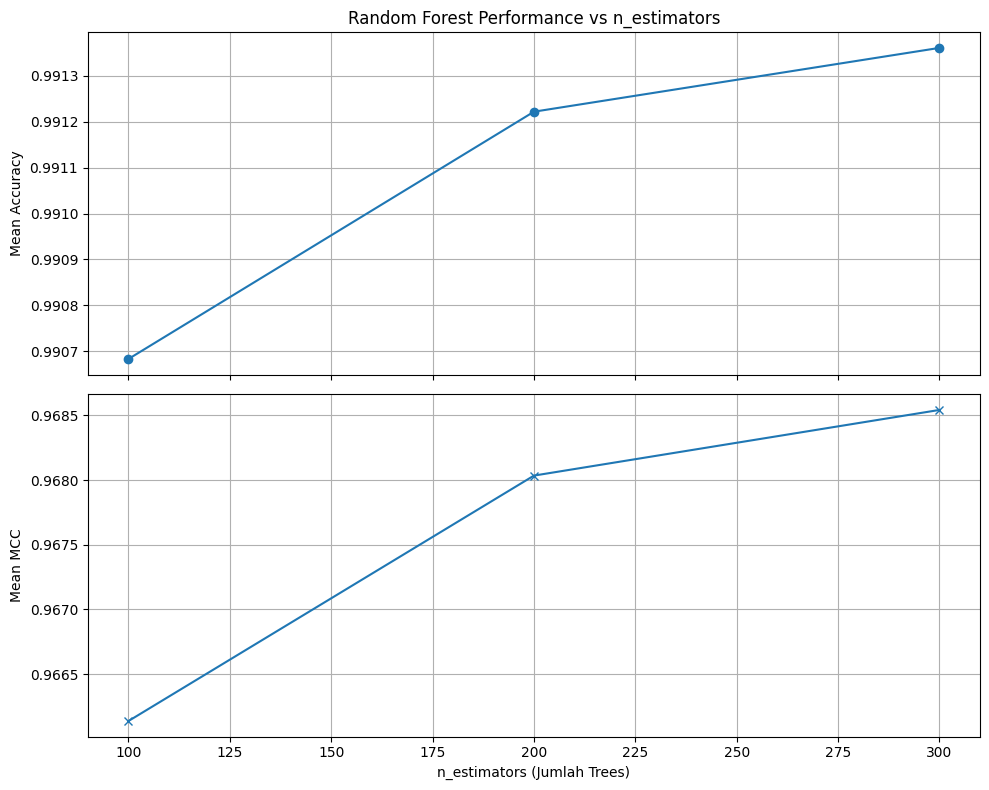

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Accuracy
axes[0].plot(n_estimators_list, mean_acc_results, marker='o')
axes[0].set_ylabel('Mean Accuracy')
axes[0].set_title('Random Forest Performance vs n_estimators')
axes[0].grid(True)

# MCC
axes[1].plot(n_estimators_list, mean_mcc_results, marker='x')
axes[1].set_xlabel('n_estimators (Jumlah Trees)')
axes[1].set_ylabel('Mean MCC')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# **KNN**

In [ ]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef
import numpy as np

n_neighbors_list = [1, 3, 5, 7, 9, 11]

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# Final results
mean_acc_knn = []
mean_mcc_knn = []
mean_train_knn = []
mean_pred_knn = []

for k in n_neighbors_list:

    print("\n\n======================")
    print(f"        K = {k}")
    print("======================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []

    fold_counter = 1

    for train_idx, test_idx in rskf.split(X_train, y_train):

        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        model = KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            p=2
        )

        # Training time
        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        # Prediction time
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} =====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediction Time: {pred_time:.5f} sec")
        fold_counter += 1

    # Store mean results
    mean_acc_knn.append(np.mean(acc_all))
    mean_mcc_knn.append(np.mean(mcc_all))
    mean_train_knn.append(np.mean(train_time_all))
    mean_pred_knn.append(np.mean(predict_time_all))

    print("\n>>> RESULT for K =", k)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {np.mean(train_time_all):.5f} sec")
    print(f"Mean Predict Time:  {np.mean(predict_time_all):.5f} sec")



        K = 1

===== Fold 1 =====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'η', 'N2', 'η2', 'T', 'V', 'N_hat', 'E', 'B', 'N1', 'D']
Accuracy: 0.97871
MCC: 0.92050
Training Time:  0.01847 sec
Prediction Time: 0.02675 sec

===== Fold 2 =====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η2', 'N_hat', 'N', 'η', 'T', 'E', 'N2', 'V', 'B', 'N1', 'D']
Accuracy: 0.97957
MCC: 0.92374
Training Time:  0.01760 sec
Prediction Time: 0.02781 sec

===== Fold 3 =====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'N2', 'η', 'E', 'T', 'η2', 'N_hat', 'B', 'V', 'D', 'N1']
Accuracy: 0.97827
MCC: 0.91931
Training Time:  0.01830 sec
Prediction Time: 0.02705 sec

===== Fold 4 =====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η2', 'η', 'N', 'N_hat', 'N2', 'T', 'E', 'V', 'B', 'N1', 'D']
Accuracy: 0.97827
MCC: 0.91800
Training Time:  0.01767 sec
Prediction Time: 0.02621 sec

===== Fold 5 =====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η', 'η2', 'N', 'N_hat',

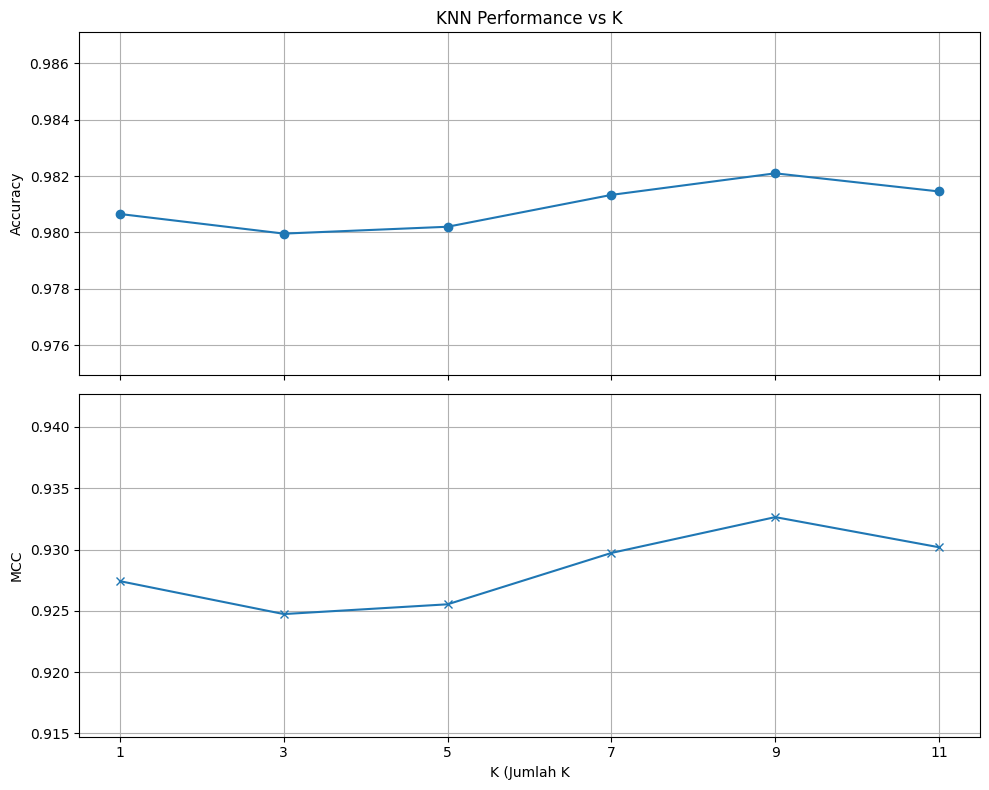

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ---- Accuracy ----
axes[0].plot(n_neighbors_list, mean_acc_knn, marker='o')
axes[0].set_ylabel("Accuracy")
axes[0].set_title("KNN Performance vs K")
axes[0].grid(True)
axes[0].set_ylim(min(mean_acc_knn)-0.005, max(mean_acc_knn)+0.005)

# ---- MCC ----
axes[1].plot(n_neighbors_list, mean_mcc_knn, marker='x')
axes[1].set_xlabel("K (Jumlah K")
axes[1].set_ylabel("MCC")
axes[1].grid(True)
axes[1].set_ylim(min(mean_mcc_knn)-0.01, max(mean_mcc_knn)+0.01)

# Set X-ticks agar sesuai angka K
plt.xticks(n_neighbors_list)

plt.tight_layout()
plt.show()

# **LOGISTIC REGRESION**

In [ ]:
import time
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, matthews_corrcoef

C_list = [0.001, 0.01, 0.1, 1, 10, 100]

mean_acc_lr = []
mean_mcc_lr = []

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

print("\n===============================")
print("  LOGISTIC REGRESSION EVALUATION")
print("===============================\n")

for C in C_list:

    print("\n\n=====================")
    print(f"        C = {C}")
    print("=====================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []
    fold_counter = 1

    for train_idx, test_idx in rskf.split(X_train, y_train):

        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        # Feature Selection
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # Scaling
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # Model
        model = LogisticRegression(C=C, max_iter=3000, solver='lbfgs')

        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediction Time:{pred_time:.5f} sec")

        fold_counter += 1

    # Simpan hasil rata-rata
    mean_acc_lr.append(np.mean(acc_all))
    mean_mcc_lr.append(np.mean(mcc_all))

    print("\n>>> RESULT for C =", C)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {np.mean(train_time_all):.5f} sec")
    print(f"Mean Predict Time:  {np.mean(predict_time_all):.5f} sec")


  LOGISTIC REGRESSION EVALUATION



        C = 0.001

===== Fold 1 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'η', 'N2', 'η2', 'T', 'V', 'N_hat', 'E', 'B', 'N1', 'D']
Accuracy: 0.97480
MCC: 0.90429
Training Time:  0.22513 sec
Prediction Time:0.00173 sec

===== Fold 2 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η2', 'N_hat', 'N', 'η', 'T', 'E', 'N2', 'V', 'B', 'N1', 'D']
Accuracy: 0.97957
MCC: 0.92282
Training Time:  0.19778 sec
Prediction Time:0.00174 sec

===== Fold 3 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'N2', 'η', 'E', 'T', 'η2', 'N_hat', 'B', 'V', 'D', 'N1']
Accuracy: 0.97870
MCC: 0.91917
Training Time:  0.13537 sec
Prediction Time:0.00167 sec

===== Fold 4 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η2', 'η', 'N', 'N_hat', 'N2', 'T', 'E', 'V', 'B', 'N1', 'D']
Accuracy: 0.97436
MCC: 0.90242
Training Time:  0.16228 sec
Prediction Time:0.00187 sec

===== Fold 5 ====
Selected features: ['wmc', 'lloc', 'sloc', 'bl

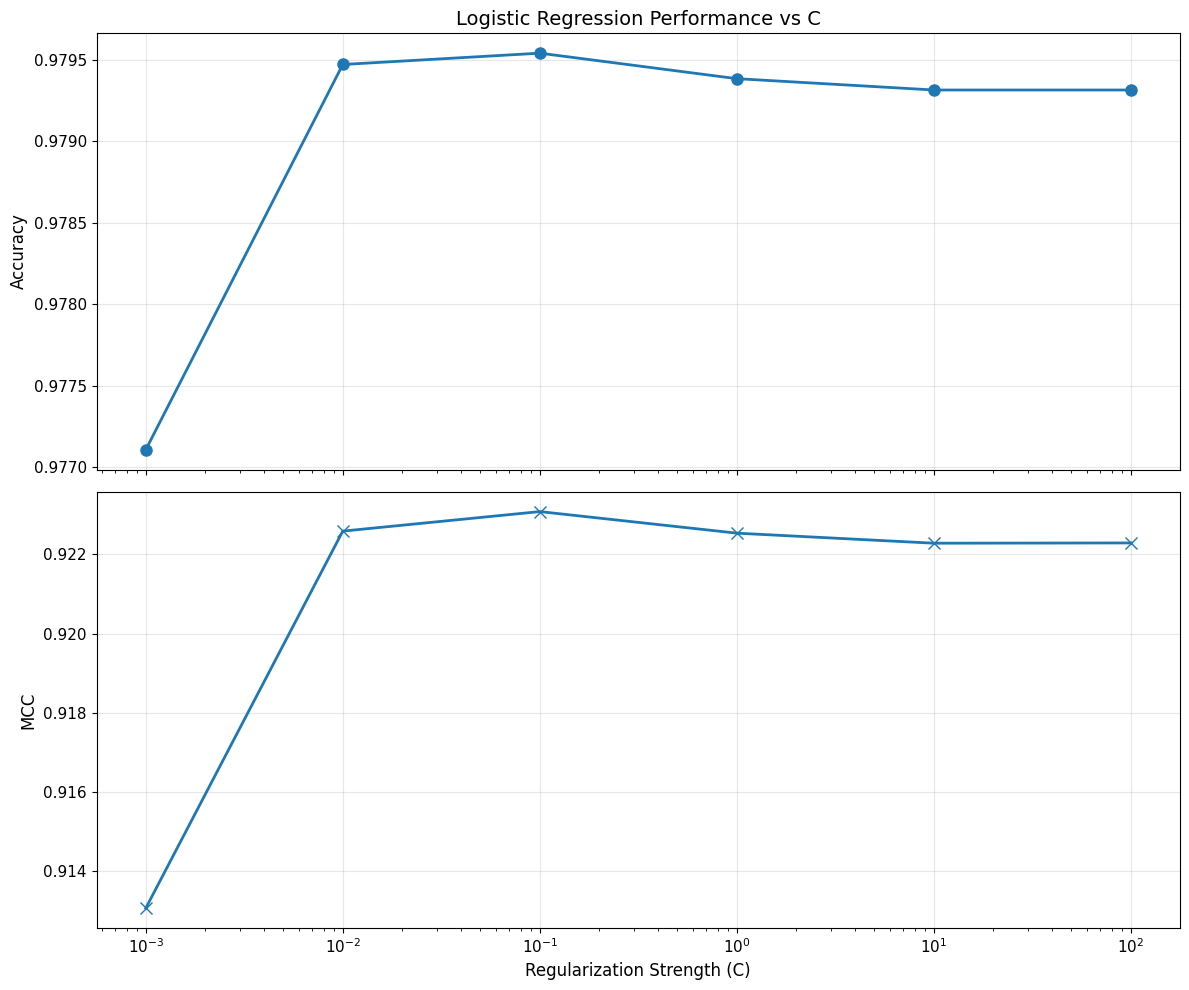

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Accuracy
axes[0].plot(C_list, mean_acc_lr, marker='o', linewidth=2, markersize=8)
axes[0].set_xscale('log')
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Logistic Regression Performance vs C", fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='both', labelsize=11)

# MCC
axes[1].plot(C_list, mean_mcc_lr, marker='x', linewidth=2, markersize=8)
axes[1].set_xscale('log')
axes[1].set_xlabel("Regularization Strength (C)", fontsize=12)
axes[1].set_ylabel("MCC", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='both', labelsize=11)

# Set X-ticks agar sesuai angka
plt.xticks(C_list)

plt.tight_layout()
plt.show()

# **MLP**

In [ ]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix
import numpy as np

# Hyperparameter MLP
hidden_layer_sizes_list = [4, 8, 16, 32, 64, 100]

# Untuk menyimpan hasil mean
mean_acc_mlp = []
mean_mcc_mlp = []
train_time_all = []
predict_time_all = []
fold_counter = 1

# Repeated CV
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

print("\n===============================")
print("      MLP CLASSIFIER EVALUATION")
print("===============================\n")

for h in hidden_layer_sizes_list:

    print("\n\n======================")
    print(f"  Hidden Layer = {h}")
    print("======================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []

    fold_counter = 1

    # ==== Cross Validation ====
    for train_idx, test_idx in rskf.split(X_train, y_train):

        # Ambil fold
        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        # Feature selection
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # Scaling per fold
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # ==== MLP Model ====
        model = MLPClassifier(
            hidden_layer_sizes=(h,),   # satu hidden layer
            activation='relu',
            solver='adam',
            max_iter=2000,
            random_state=42
        )

        # === Timing Training ===
        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        # === Timing Predict ===
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        model.fit(X_train_scaled, y_train_fold)
        y_pred = model.predict(X_test_scaled)

        # === Evaluasi ===
        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediksi Time:  {pred_time:.5f} sec")
        fold_counter += 1

    # === Hasil per konfigurasi Hidden Layer ===
    mean_acc_mlp.append(np.mean(acc_all))
    mean_mcc_mlp.append(np.mean(mcc_all))
    mean_train = np.mean(train_time_all)
    mean_pred = np.mean(predict_time_all)

    print("\n>>> RESULT for Hidden Layer =", hidden_layer_sizes_list)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {mean_train:.5f} sec")
    print(f"Mean Predict Time:  {mean_pred:.5f} sec")


      MLP CLASSIFIER EVALUATION



  Hidden Layer = 4

===== Fold 1 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'η', 'N2', 'η2', 'T', 'V', 'N_hat', 'E', 'B', 'N1', 'D']
Accuracy: 0.97698
MCC: 0.91273
Training Time:  3.41452 sec
Prediksi Time:  0.00161 sec

===== Fold 2 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η2', 'N_hat', 'N', 'η', 'T', 'E', 'N2', 'V', 'B', 'N1', 'D']
Accuracy: 0.98044
MCC: 0.92659
Training Time:  2.26376 sec
Prediksi Time:  0.00180 sec

===== Fold 3 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'N2', 'η', 'E', 'T', 'η2', 'N_hat', 'B', 'V', 'D', 'N1']
Accuracy: 0.97957
MCC: 0.92282
Training Time:  3.58394 sec
Prediksi Time:  0.00261 sec

===== Fold 4 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η2', 'η', 'N', 'N_hat', 'N2', 'T', 'E', 'V', 'B', 'N1', 'D']
Accuracy: 0.96654
MCC: 0.87224
Training Time:  2.43890 sec
Prediksi Time:  0.00148 sec

===== Fold 5 ====
Selected features: ['wmc', 'lloc', 'sloc', 'bl

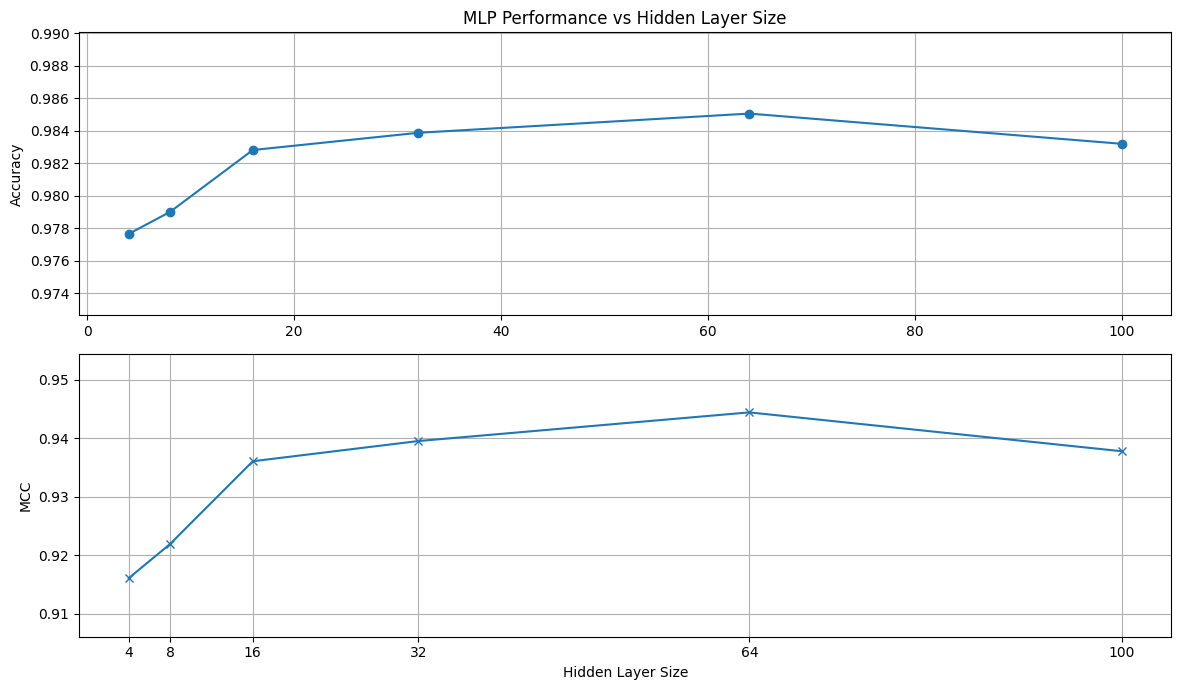

In [ ]:
plt.figure(figsize=(12, 7))

# ==== Plot Accuracy ====
plt.subplot(2, 1, 1)
plt.plot(hidden_layer_sizes_list, mean_acc_mlp, marker='o')
plt.title("MLP Performance vs Hidden Layer Size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.ylim(min(mean_acc_mlp) - 0.005, max(mean_acc_mlp) + 0.005)

# ==== Plot MCC ====
plt.subplot(2, 1, 2)
plt.plot(hidden_layer_sizes_list, mean_mcc_mlp, marker='x')
plt.xlabel("Hidden Layer Size")
plt.ylabel("MCC")
plt.grid(True)
plt.ylim(min(mean_mcc_mlp) - 0.01, max(mean_mcc_mlp) + 0.01)

# Set X-ticks agar sesuai angka
plt.xticks(hidden_layer_sizes_list)

plt.tight_layout()
plt.show()

# **TABNET**

In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00


In [ ]:
import time
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, matthews_corrcoef
import numpy as np
import torch
import pandas as pd # Ensure pandas is imported

# Hyperparameter list
n_d_a_list = [8, 16, 32, 64]

mean_acc_tabnet = []
mean_mcc_tabnet = []

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

print("\n===============================")
print("         TABNET EVALUATION")
print("===============================\n")

for dim in n_d_a_list:

    print(f"\n\n======================\n  n_d = n_a = {dim}\n======================")

    acc_all = []
    mcc_all = []
    train_time_all_fold = [] # Renamed to avoid conflict with outer scope
    predict_time_all_fold = [] # Renamed to avoid conflict with outer scope
    fold_counter = 1

    for train_idx, test_idx in rskf.split(X_train, y_train):

        # === Ambil fold ===
        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx].values
        y_test_fold  = y_train.iloc[test_idx].values

        # === Feature Selection per fold ===
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)

        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # === Scaling per fold ===
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # TabNet expects numpy arrays, so convert after scaling if they are DataFrames
        X_train_scaled_tabnet = X_train_scaled.values if isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled
        X_test_scaled_tabnet = X_test_scaled.values if isinstance(X_test_scaled, pd.DataFrame) else X_test_scaled

        # === Model TabNet ===
        model = TabNetClassifier(
            n_d=dim,
            n_a=dim,
            n_steps=5,
            gamma=1.3,
            lambda_sparse=1e-4,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=1e-3),
            verbose=0,
            seed=42 # Added seed for reproducibility
        )

        # === Timing Training ===
        start_train = time.time()
        model.fit(
            X_train_scaled_tabnet, y_train_fold,
            eval_set=[(X_test_scaled_tabnet, y_test_fold)],
            eval_metric=['accuracy'],
            max_epochs=100,
            patience=30
        )
        train_time = time.time() - start_train

        # === Timing Predict ===
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled_tabnet)
        pred_time = time.time() - start_pred

        # === Evaluasi ===
        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all_fold.append(train_time)
        predict_time_all_fold.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediksi Time:  {pred_time:.5f} sec")
        fold_counter += 1

    # === Hasil per konfigurasi hidden dimension ===
    mean_acc_tabnet.append(np.mean(acc_all))
    mean_mcc_tabnet.append(np.mean(mcc_all))
    mean_train = np.mean(train_time_all_fold)
    mean_pred = np.mean(predict_time_all_fold)

    print(f"\n>>> RESULT for n_d = n_a = {dim}")
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {mean_train:.5f} sec")
    print(f"Mean Predict Time:  {mean_pred:.5f} sec")


         TABNET EVALUATION



  n_d = n_a = 8

Early stopping occurred at epoch 54 with best_epoch = 24 and best_val_0_accuracy = 0.95352


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 1 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'η', 'N2', 'η2', 'T', 'V', 'N_hat', 'E', 'B', 'N1', 'D']
Accuracy: 0.95352
MCC: 0.81981
Training Time:  55.31450 sec
Prediksi Time:  0.11551 sec

Early stopping occurred at epoch 50 with best_epoch = 20 and best_val_0_accuracy = 0.95437


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 2 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'η2', 'N_hat', 'N', 'η', 'T', 'E', 'N2', 'V', 'B', 'N1', 'D']
Accuracy: 0.95437
MCC: 0.82962
Training Time:  30.48619 sec
Prediksi Time:  0.06891 sec

Early stopping occurred at epoch 48 with best_epoch = 18 and best_val_0_accuracy = 0.94307


...


===== Fold 23 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'η2', 'N_hat', 'η', 'N2', 'E', 'T', 'B', 'V', 'N1', 'D']
Accuracy: 0.98044
MCC: 0.92591
Training Time:  111.83084 sec
Prediksi Time:  0.16648 sec
Stop training because you reached max_epochs = 100 with best_epoch = 91 and best_val_0_accuracy = 0.98435


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 24 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'N2', 'N_hat', 'T', 'η', 'η2', 'E', 'B', 'V', 'N1', 'D']
Accuracy: 0.98435
MCC: 0.94101
Training Time:  173.11948 sec
Prediksi Time:  0.19076 sec

Early stopping occurred at epoch 67 with best_epoch = 37 and best_val_0_accuracy = 0.98218


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 25 ====
Selected features: ['wmc', 'lloc', 'sloc', 'blank', 'N', 'N_hat', 'η2', 'η', 'N2', 'E', 'T', 'V', 'B', 'N1', 'D']
Accuracy: 0.98218
MCC: 0.93279
Training Time:  119.55073 sec
Prediksi Time:  0.18429 sec

>>> RESULT for n_d = n_a = 64
Mean Accuracy: 0.98331
Mean MCC: 0.93700
Mean Train Time:    139.76263 sec
Mean Predict Time:  0.17074 sec


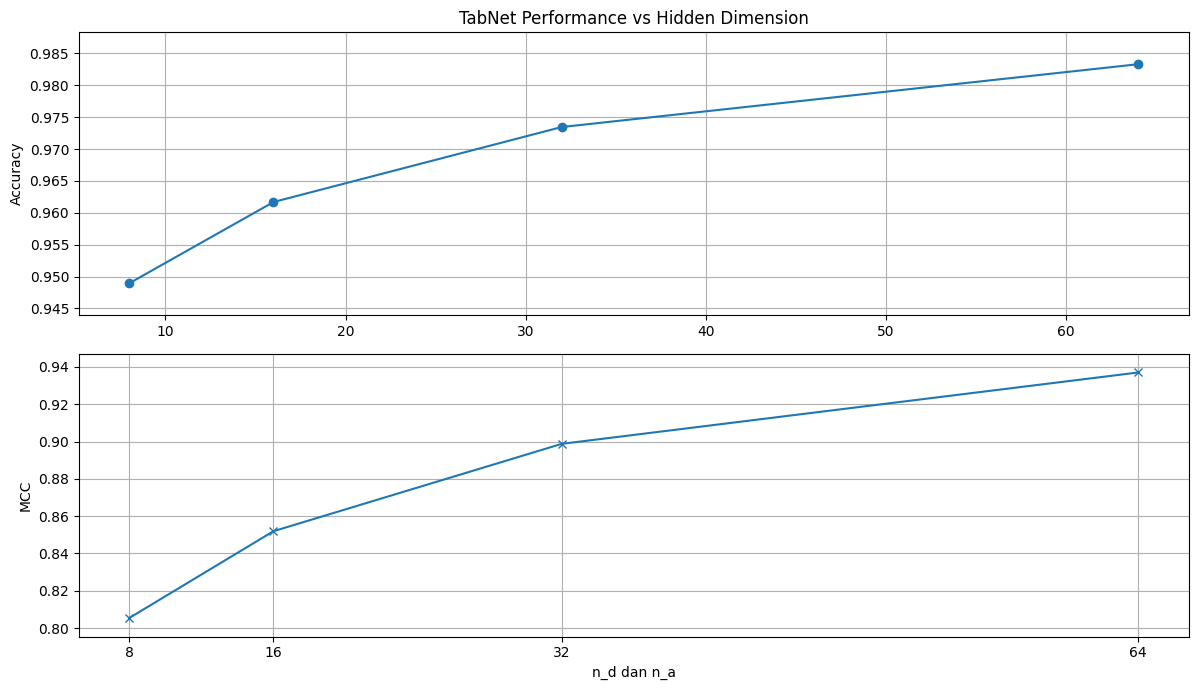

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plot Accuracy
plt.subplot(2, 1, 1)
plt.plot(n_d_a_list, mean_acc_tabnet, marker='o')
plt.title("TabNet Performance vs Hidden Dimension")
plt.ylabel("Accuracy")
plt.grid(True)
plt.ylim(min(mean_acc_tabnet) - 0.005, max(mean_acc_tabnet) + 0.005)

# Plot MCC
plt.subplot(2, 1, 2)
plt.plot(n_d_a_list, mean_mcc_tabnet, marker='x')
plt.xlabel("n_d dan n_a")
plt.ylabel("MCC")
plt.grid(True)
plt.ylim(min(mean_mcc_tabnet) - 0.01, max(mean_mcc_tabnet) + 0.01)

# Set X-ticks agar sesuai angka
plt.xticks(n_d_a_list)

plt.tight_layout()
plt.show()